# 4. Refining an EclipseNET from trajectory data

The shape of a small body is often poorly known before a spacecraft gets there, and so is its EclipseNET. Section 4 of the paper refines the network directly from trajectory data: since the network is the event function that switches the radiation pressure, the trajectory depends on its weights $\boldsymbol{\theta}$, and the weights can be optimized to minimize the distance between the propagated states and the observed ones (Eq. 4):

$$\mathcal{L} = \sum_j \| \mathbf{x}_{\boldsymbol{\theta}}(t_j) - \bar{\mathbf{x}}_j \|^2$$

**How the gradient is computed.** The weights only enter the dynamics through the times at which the eclipse factor switches. At a switch, at the time $t^*$ where the event function $e_{\boldsymbol{\theta}}$ vanishes, the sensitivity $\mathbf{S} = \partial \mathbf{x} / \partial \boldsymbol{\theta}$ jumps:

$$\frac{\partial t^*}{\partial \boldsymbol{\theta}} = -\frac{\nabla_{\boldsymbol{\theta}} e_{\boldsymbol{\theta}} + \nabla_{\mathbf{x}} e_{\boldsymbol{\theta}} \, \mathbf{S}^-}{\dot{e}_{\boldsymbol{\theta}}}, \qquad \mathbf{S}^+ = \mathbf{S}^- + (\mathbf{f}^- - \mathbf{f}^+) \, \frac{\partial t^*}{\partial \boldsymbol{\theta}}$$

where $\mathbf{f}^-$ and $\mathbf{f}^+$ are the dynamics before and after the switch. Between two switches the dynamics do not depend on the weights, and the state transition matrix carries $\mathbf{S}$ forward. This gives the same sensitivities as the variational equations with respect to the weights (Eq. 7 of the paper), while integrating 36 variational equations instead of 6 for each of the 2,369 weights. The derivatives of the network come from `torch`, the state transition matrix from heyoka.

This notebook reproduces the experiment of Figure 5: an orbit around 67P, a network taken from the first epoch of training, and a single observation of the state at the final time.

In [1]:
import sys
sys.path.append('../')  # the repository root, where the eclipsenets package is

import numpy as np
import torch
import matplotlib.pyplot as plt

import eclipsenets as en

## A network that is not accurate yet

The starting point is the feed-forward network of 67P after its first epoch of training. Its silhouettes miss the concavities of the comet:

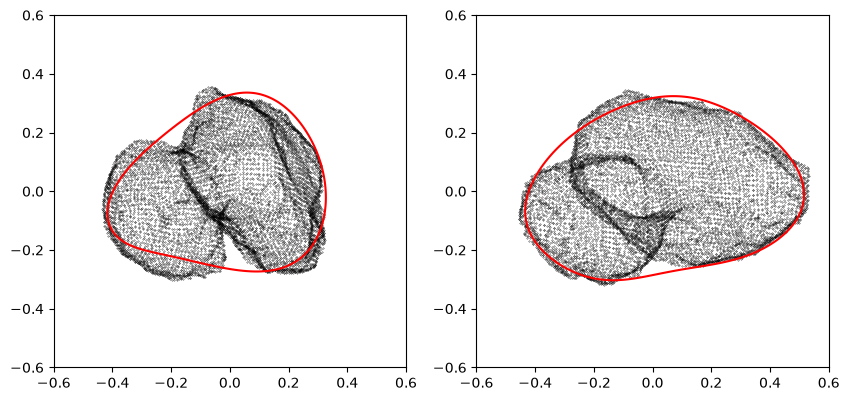

In [2]:
body = en.load_body("67P")
model = en.load_pretrained("67P", "ffnn", epoch=0)
initial_model = en.load_pretrained("67P", "ffnn", epoch=0)  # kept for the comparison

views = [en.sph2cart(az=30., el=100.), en.sph2cart(az=120., el=75.)]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, view in zip(axes, views):
    projected = en.project_to_2d(body.mesh_points, view)
    ax.plot(projected[:, 0], projected[:, 1], '.', color='black', markersize=0.5)
    en.plot_silhouette(initial_model, view, ax=ax, extent=0.6, colors='red')

## The observation

The orbit is the one of notebook 3. The observed state is the one at the final time of a propagation with ray tracing, which plays the role of the real trajectory.

In [3]:
sun_direction = np.array([-1., -1., 0.]) / np.sqrt(2)
SRP = 1e-3
ic = en.initial_state(radius=1.5, inclination=np.radians(11.), omega=body.omega)
tgrid = np.linspace(0, 3 * np.pi, 240)

truth = en.propagate_ray_tracing(body, ic, tgrid, sun_direction, srp=SRP)

times = tgrid[[0, -1]]      # initial time and time of the observation
observations = truth[[-1]]  # the observed state
print(f"Observation at t = {times[-1]:.3f}")

Observation at t = 9.425


With the initial network, the propagated trajectory drifts away from the real one:

In [4]:
before = en.EclipseNetPropagator(body, initial_model).propagate(ic, tgrid, sun_direction, srp=SRP)
errors_before = (before.states[:, :3] - truth[:, :3]) * body.L
print(f"{len(before.eclipses)} eclipses, position error at the final time: {np.linalg.norm(errors_before[-1]):.2f} m")

6 eclipses, position error at the final time: 3.26 m


## Sensitivities with respect to the weights

The refinement needs a propagator built with two options: `learnable=True` makes the weights of the network runtime parameters of the integrator, so that they can change without building a new one, and `variational=True` propagates the state transition matrix. The tolerance is relaxed to $10^{-9}$ (still far below the errors at play) to speed up the variational equations.

`state_sensitivities` returns the derivatives of the propagated states with respect to the weights. They are checked here against finite differences, along a random direction of the space of the weights.

In [5]:
propagator = en.EclipseNetPropagator(body, model, learnable=True, variational=True, tol=1e-9)
model.double()

propagation = propagator.propagate(ic, times, sun_direction, srp=SRP)
sensitivities = en.state_sensitivities(model, propagation, sun_direction, SRP, body.omega, propagator.r_gate)
print(f"Sensitivities of {sensitivities.shape[0]} states with {sensitivities.shape[1]} components "
      f"with respect to {sensitivities.shape[2]:,} weights")

parameters = list(model.parameters())
theta = torch.nn.utils.parameters_to_vector(parameters).detach().clone()
direction = torch.tensor(np.random.default_rng(0).normal(size=len(theta)))
direction /= direction.norm()

final_states = []
for step in [1e-4, -1e-4]:
    torch.nn.utils.vector_to_parameters(theta + step * direction, parameters)
    propagator.set_weights(model)
    final_states.append(propagator.propagate(ic, times, sun_direction, srp=SRP).states[-1])
torch.nn.utils.vector_to_parameters(theta, parameters)

print("Derivative of the final state along the direction")
print("  sensitivities:     ", sensitivities[-1] @ direction.numpy())
print("  finite differences:", (final_states[0] - final_states[1]) / 2e-4)

Sensitivities of 2 states with 6 components with respect to 2,369 weights


Derivative of the final state along the direction
  sensitivities:      [ 8.61823046e-04  2.01285344e-04 -3.20299005e-05  3.17819123e-04
 -2.09997167e-03 -3.20110194e-05]
  finite differences: [ 8.61823359e-04  2.01285446e-04 -3.20299164e-05  3.17819278e-04
 -2.09997240e-03 -3.20110313e-05]


## Refinement

`refine` minimizes the loss with Adam, propagating the trajectory and its sensitivities at every iteration (about 8 seconds each). The model is modified in place, and is left with the best weights found.

In [6]:
losses = en.refine(propagator, model, ic, times, observations, sun_direction, srp=SRP,
                   n_iterations=20, learning_rate=1e-4)

Iteration 0/20 - Loss: 2.831538e-06


Iteration 1/20 - Loss: 2.829702e-07


Iteration 2/20 - Loss: 4.177746e-08


Iteration 3/20 - Loss: 2.344328e-08


Iteration 4/20 - Loss: 5.413341e-09


...

Iteration 16/20 - Loss: 6.314201e-09


Iteration 17/20 - Loss: 4.300757e-09


Iteration 18/20 - Loss: 3.522491e-09


Iteration 19/20 - Loss: 3.808556e-09


Iteration 20/20 - Loss: 4.823415e-09


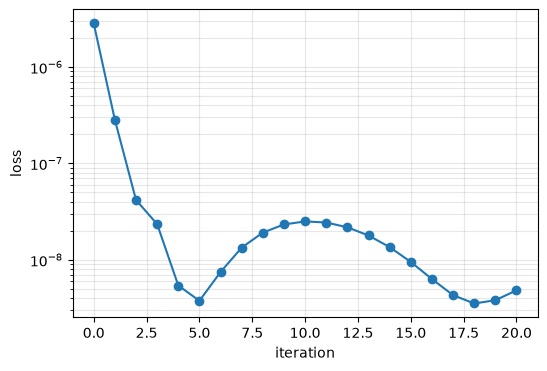

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(losses, 'o-')
ax.set_xlabel('iteration')
ax.set_ylabel('loss')
ax.grid(True, which='both', alpha=0.3)

## Figure 5 of the paper

Left: the orbit, with the eclipses found by the refined network. Right: the position error with respect to the real trajectory before (red) and after (green) the refinement; the dashed lines are the norms of the two errors, the gray bands the eclipses.

Position error at the final time: 3.26 m before, 0.18 m after (a factor 18)


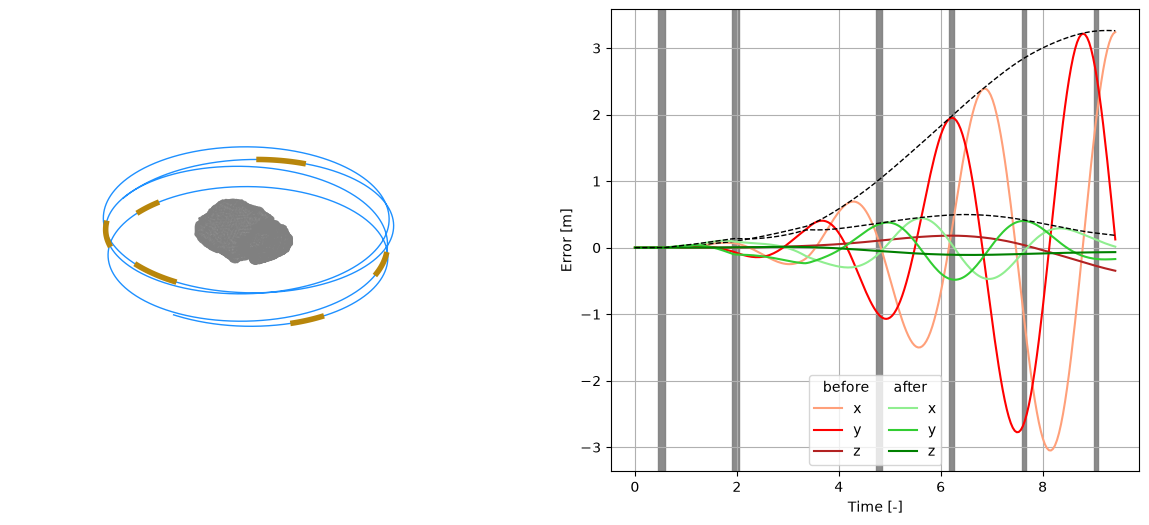

In [8]:
refined = en.EclipseNetPropagator(body, model)
after = refined.propagate(ic, tgrid, sun_direction, srp=SRP)
errors_after = (after.states[:, :3] - truth[:, :3]) * body.L

fig = plt.figure(figsize=(15, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(*body.mesh_points.T, s=0.2, color='gray')
dense = np.linspace(tgrid[0], tgrid[-1], 4000)
orbit = refined.propagate(ic, dense, sun_direction, srp=SRP).states
ax.plot(*orbit[:, :3].T, color='dodgerblue', linewidth=1)
for start, end in after.eclipses:
    ax.plot(*orbit[(dense >= start) & (dense <= end), :3].T, color='darkgoldenrod', linewidth=4)
ax.set_box_aspect(np.ptp(orbit[:, :3], axis=0))
ax.set_axis_off()

ax = fig.add_subplot(1, 2, 2)
for errors, colors in [(errors_before, ['lightsalmon', 'red', 'firebrick']), (errors_after, ['lightgreen', 'limegreen', 'green'])]:
    for i, label in enumerate('xyz'):
        ax.plot(tgrid, errors[:, i], color=colors[i], label=label)
    ax.plot(tgrid, np.linalg.norm(errors, axis=1), 'k--', linewidth=1)
for start, end in after.eclipses:
    ax.axvspan(start, end, alpha=0.9, color='gray')
ax.set_xlabel('Time [-]')
ax.set_ylabel('Error [m]')
ax.grid(True)
ax.legend(ncol=2, title='before      after')

norm_before, norm_after = np.linalg.norm(errors_before[-1]), np.linalg.norm(errors_after[-1])
print(f"Position error at the final time: {norm_before:.2f} m before, {norm_after:.2f} m after "
      f"(a factor {norm_before / norm_after:.0f})")

The refinement reduces the error of the propagated trajectory at the observation, as in the paper, which reports a reduction of the error norm by nearly a factor of 7. The errors themselves are smaller here than in Figure 5 of the paper, where the trajectory before the refinement is about 58 m off at the final time: on this orbit, the first-epoch network released with the paper is about 3 m off. The message/techniques are the same.

## The silhouette after the refinement

The two views of the beginning of the notebook, with the silhouette of the network before (red) and after (green) the refinement.

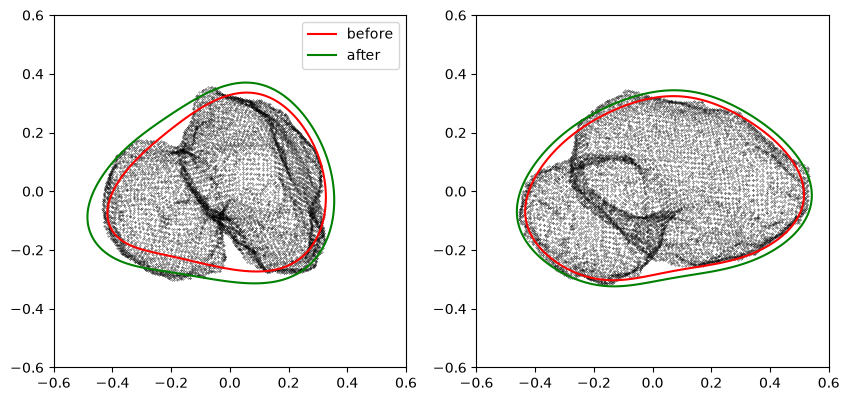

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, view in zip(axes, views):
    projected = en.project_to_2d(body.mesh_points, view)
    ax.plot(projected[:, 0], projected[:, 1], '.', color='black', markersize=0.5)
    en.plot_silhouette(initial_model, view, ax=ax, extent=0.6, colors='red')
    en.plot_silhouette(model, view, ax=ax, extent=0.6, colors='green')
axes[0].plot([], [], 'r', label='before')
axes[0].plot([], [], 'g', label='after')
axes[0].legend(loc='upper right');

The silhouette changes, but it is not perfect yet. A single observed state only constrains a combination of the times at which the eclipses start and end, and the refinement matches it by making some eclipses longer and others shorter. As the paper notes, observations from diverse geometries are needed for the silhouette itself to improve.